In [1]:
import pandas as pd
import numpy as np
import glob
from tqdm import tqdm

In [2]:
btc = pd.read_csv("../data/raw/btc_prices.csv")
btc["date"] = pd.to_datetime(btc["date"])
btc = btc.sort_values("date")

btc["return"] = np.log(btc["close"]).diff()

btc["volatility_7d"] = btc["return"].rolling(7).std()
btc["volatility_14d"] = btc["return"].rolling(14).std()
btc["volatility_30d"] = btc["return"].rolling(30).std()

btc = btc.sort_values("date").drop_duplicates("date").reset_index(drop=True)

btc.head(10)


,date,open,high,low,close,volume,return,volatility_7d,volatility_14d,volatility_30d
0,2015-01-02,314.079010,315.838989,313.565002,315.032013,7860650,NaN,NaN,NaN,NaN
1,2015-01-03,314.846008,315.149994,281.082001,281.082001,33054400,-0.114028,NaN,NaN,NaN
2,2015-01-04,281.145996,287.230011,257.612000,264.195007,55629100,-0.061959,NaN,NaN,NaN
3,2015-01-05,265.084015,278.341003,265.084015,274.473999,43962800,0.038169,NaN,NaN,NaN
4,2015-01-06,274.610992,287.553009,272.696014,286.188995,23245700,0.041796,NaN,NaN,NaN
5,2015-01-07,286.076996,298.753998,283.079010,294.337006,24866800,0.028073,NaN,NaN,NaN
6,2015-01-08,294.135010,294.135010,282.174988,283.348999,19982500,-0.038046,NaN,NaN,NaN
7,2015-01-09,282.382996,291.114014,280.532990,290.407990,18718600,0.024607,0.060470,NaN,NaN
8,2015-01-10,287.303009,288.127014,273.966003,274.795990,15264300,-0.055258,0.046304,NaN,NaN
9,2015-01-11,274.608002,279.638000,265.039001,265.660004,18200800,-0.033812,0.041306,NaN,NaN


In [3]:
nifty = pd.read_csv("../data/raw/nifty_prices.csv")
nifty["date"] = pd.to_datetime(nifty["date"])
nifty = nifty.sort_values("date")

nifty["return"] = np.log(nifty["close"]).diff()

nifty["volatility_7d"] = nifty["return"].rolling(7).std()
nifty["volatility_14d"] = nifty["return"].rolling(14).std()
nifty["volatility_30d"] = nifty["return"].rolling(30).std()

nifty = nifty.sort_values("date").drop_duplicates("date").reset_index(drop=True)

nifty.head(10)

,date,open,high,low,close,volume,return,volatility_7d,volatility_14d,volatility_30d
0,2010-01-05,5277.149902,5288.350098,5242.399902,5277.899902,0,NaN,NaN,NaN,NaN
1,2010-01-06,5278.149902,5310.850098,5260.049805,5281.799805,0,0.000739,NaN,NaN,NaN
2,2010-01-07,5281.799805,5302.549805,5244.750000,5263.100098,0,-0.003547,NaN,NaN,NaN
3,2010-01-08,5264.250000,5276.750000,5234.700195,5244.750000,0,-0.003493,NaN,NaN,NaN
4,2010-01-11,5263.799805,5287.200195,5227.799805,5249.399902,0,0.000886,NaN,NaN,NaN
5,2010-01-12,5251.100098,5300.500000,5200.950195,5210.399902,0,-0.007457,NaN,NaN,NaN
6,2010-01-13,5212.600098,5239.200195,5169.549805,5233.950195,0,0.004510,NaN,NaN,NaN
7,2010-01-14,5234.500000,5272.850098,5232.500000,5259.899902,0,0.004946,0.004562,NaN,NaN
8,2010-01-15,5259.899902,5279.850098,5242.450195,5252.200195,0,-0.001465,0.004539,NaN,NaN
9,2010-01-18,5253.649902,5292.500000,5228.950195,5274.850098,0,0.004303,0.004714,NaN,NaN


In [6]:
btc["date"] = pd.to_datetime(btc["date"], errors="coerce")
btc = btc.dropna(subset=["date"])
btc["date"] = btc["date"].dt.normalize()
btc = btc.set_index("date").sort_index()

print("BTC:", btc.index.min(), "→", btc.index.max(), "rows:", len(btc))

nifty["date"] = pd.to_datetime(nifty["date"], errors="coerce")
nifty = nifty.dropna(subset=["date"])
nifty["date"] = nifty["date"].dt.normalize()
nifty = nifty.set_index("date").sort_index()

print("NIFTY:", nifty.index.min(), "→", nifty.index.max(), "rows:", len(nifty))

BTC: 2015-01-02 00:00:00 → 2025-12-30 00:00:00 rows: 4016
NIFTY: 2010-01-05 00:00:00 → 2025-12-30 00:00:00 rows: 3927


In [7]:
events = pd.read_csv("../data/processed/events_daily_2015_2025.csv")
events["date"] = pd.to_datetime(events["date"])
events = events.sort_values("date")

events.head()

,date,event_count,avg_goldstein,neg_event_share,conflict_events,economic_events,political_events
0,2015-01-01,36544,0.184996,0.339317,0,0,0
1,2015-01-02,47315,0.131552,0.343443,0,0,0
2,2015-01-03,35158,0.069165,0.347488,0,0,0
3,2015-01-04,37364,0.363583,0.323065,0,0,0
4,2015-01-05,62579,0.418701,0.324837,0,0,0


In [11]:
# Make sure date column is datetime
events["date"] = pd.to_datetime(events["date"], errors="coerce")

# Drop bad dates (safety)
events = events.dropna(subset=["date"])

# Normalize to day-level (important)
events["date"] = events["date"].dt.normalize()

# SET AS INDEX
events = events.set_index("date").sort_index()

print("Events:", events.index.min(), "→", events.index.max(), "rows:", len(events))

Events: 2015-01-01 00:00:00 → 2025-12-31 00:00:00 rows: 3998


In [12]:
print("Events:", events.index.min(), "→", events.index.max(), "rows:", len(events))
print("BTC   :", btc.index.min(), "→", btc.index.max(), "rows:", len(btc))

Events: 2015-01-01 00:00:00 → 2025-12-31 00:00:00 rows: 3998
BTC   : 2015-01-02 00:00:00 → 2025-12-30 00:00:00 rows: 4016


In [13]:
common_dates = events.index.intersection(btc.index)
print("Common dates:", len(common_dates))

Common dates: 3996


In [16]:
df = events.join(btc[["volatility_14d"]], how="inner")

print(df.shape)
print(df.index.min(), df.index.max())

(3996, 7)
2015-01-02 00:00:00 2025-12-30 00:00:00


In [19]:
stress_features = [
    "event_count",
    "neg_event_share",
    "conflict_events",
    "economic_events",
    "political_events",
    "avg_goldstein"
]

X = events[stress_features].copy()

# Invert Goldstein: negative = stress
X["avg_goldstein"] = -X["avg_goldstein"]

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
events["GMSI"] = X_scaled.mean(axis=1)
events["GMSI"].describe()

count    3.998000e+03
mean     6.931257e-17
std      3.340603e-01
min     -1.254216e+00
25%     -2.054981e-01
50%     -8.926608e-03
75%      1.870738e-01
max      1.831775e+00
Name: GMSI, dtype: float64

In [25]:
df = events[["GMSI"]].join(
    btc[["volatility_14d"]],
    how="inner"
)

print(df.shape)
print(df.head())

(3996, 2)
                GMSI  volatility_14d
date                                
2015-01-02  0.405971             NaN
2015-01-03  0.397894             NaN
2015-01-04 -0.017225             NaN
2015-01-05  0.142630             NaN
2015-01-06  0.313414             NaN


In [26]:
df_clean = df.dropna(subset=["volatility_14d"])

print(df_clean.shape)
print(df_clean.head())

(3982, 2)
                GMSI  volatility_14d
date                                
2015-01-16  0.670766        0.098944
2015-01-17  0.508910        0.096068
2015-01-18  0.170910        0.097590
2015-01-19  0.476047        0.096967
2015-01-20  0.379153        0.095465


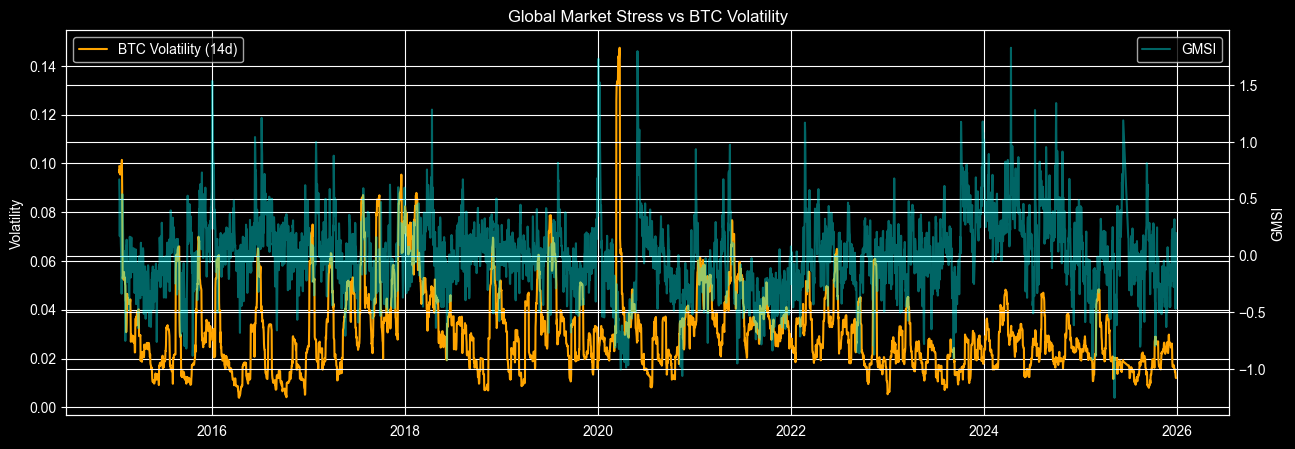

In [27]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(15,5))

ax1.plot(df_clean.index, df_clean["volatility_14d"],
         color="orange", label="BTC Volatility (14d)")
ax1.set_ylabel("Volatility")

ax2 = ax1.twinx()
ax2.plot(df_clean.index, df_clean["GMSI"],
         color="cyan", alpha=0.4, label="GMSI")
ax2.set_ylabel("GMSI")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("Global Market Stress vs BTC Volatility")
plt.show()

In [29]:
df_clean = df_clean.copy()
df_clean.loc[:, "dGMSI"] = df_clean["GMSI"].diff()

df_clean[["dGMSI", "volatility_14d"]].corr()

,dGMSI,volatility_14d
dGMSI,1.000000,-0.004954
volatility_14d,-0.004954,1.000000


In [30]:
from sklearn.cluster import KMeans

X = df_clean[["GMSI", "volatility_14d"]].dropna()

kmeans = KMeans(n_clusters=3, random_state=42)
df_clean.loc[X.index, "regime"] = kmeans.fit_predict(X)

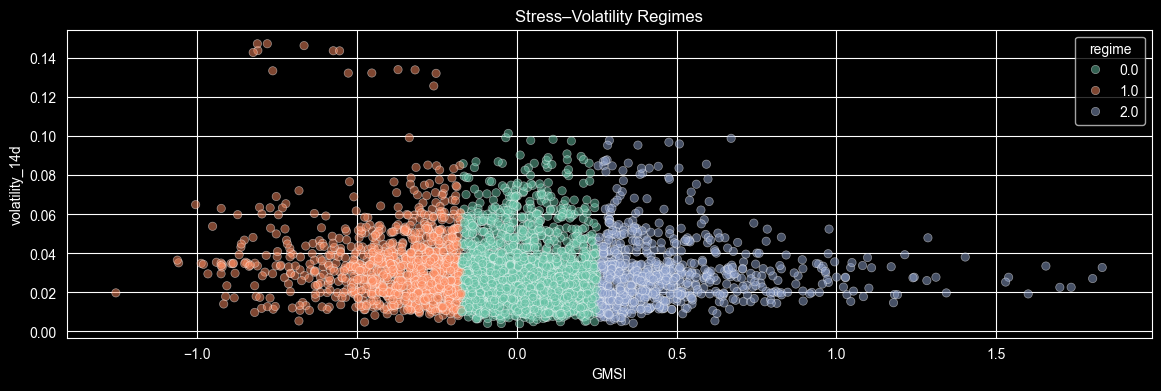

In [31]:
import seaborn as sns

plt.figure(figsize=(14,4))
sns.scatterplot(
    x="GMSI",
    y="volatility_14d",
    hue="regime",
    data=df_clean,
    palette="Set2",
    alpha=0.5
)
plt.title("Stress–Volatility Regimes")
plt.show()


In [32]:
df_clean.groupby("regime")[["GMSI","volatility_14d"]].mean()

,GMSI,volatility_14d
regime,,
0.0,0.027268,0.029661
1.0,-0.374394,0.033550
2.0,0.479744,0.030475


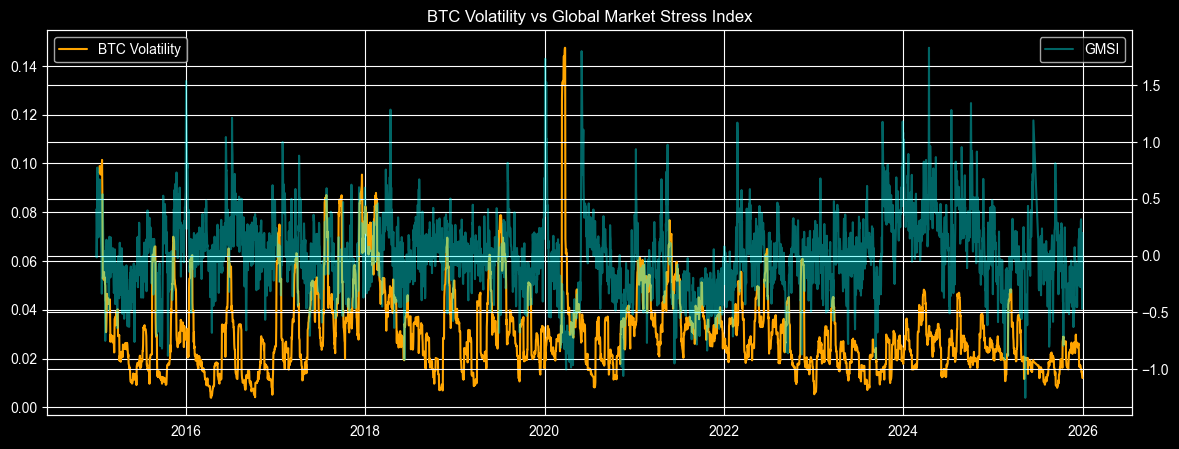

In [13]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14,5))

ax1.plot(df["date"], df["volatility_14d"], color="orange", label="BTC Volatility")
ax2 = ax1.twinx()
ax2.plot(df["date"], df["GMSI"], color="cyan", alpha=0.4, label="GMSI")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("BTC Volatility vs Global Market Stress Index")
plt.show()

In [14]:
from statsmodels.tsa.stattools import acf

acf_vals = acf(events["GMSI"], nlags=30)
events["GMSI"].skew(), events["GMSI"].kurtosis()

(0.45945016894261087, 1.9015213389854941)

<Axes: xlabel='year'>

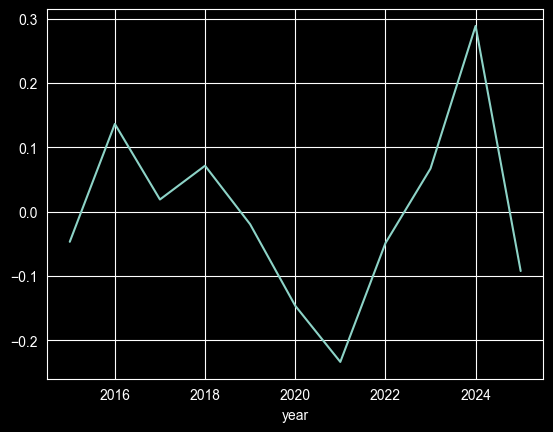

In [15]:
events["year"] = events["date"].dt.year
events.groupby("year")["GMSI"].mean().plot()

In [16]:
# Align BTC volatility and GMSI
aligned = (
    btc[["volatility_14d"]]
    .join(events.set_index("date")[["GMSI"]], how="inner")
    .dropna()
)

# Real correlation
real_corr = aligned["GMSI"].corr(aligned["volatility_14d"])

# Placebo (shuffle GMSI)
shuffled = aligned["GMSI"].sample(frac=1, random_state=42).values
placebo_corr = np.corrcoef(shuffled, aligned["volatility_14d"].values)[0, 1]

real_corr, placebo_corr

(-0.089573432378397, -0.008240951067190872)

In [17]:
for lag in [1, 3, 7, 14, 21, 30]:
    corr = aligned["GMSI"].shift(lag).corr(aligned["volatility_14d"])
    print(f"Lag {lag:>2} days: {corr:.4f}")

Lag  1 days: -0.0889
Lag  3 days: -0.0835
Lag  7 days: -0.0696
Lag 14 days: -0.0518
Lag 21 days: -0.0530
Lag 30 days: -0.0536


In [18]:
aligned["dGMSI"] = aligned["GMSI"].diff()

aligned["dGMSI"].corr(aligned["volatility_14d"])

-0.004954405850209649

In [19]:
x = aligned["GMSI"].values
y = aligned["volatility_14d"].values

mask = np.isfinite(x) & np.isfinite(y)
np.corrcoef(x[mask], y[mask])[0,1]

-0.089573432378397